# Preparing the data

## Importing the required packages

In [9]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
# from eofs.xarray import Eof

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 18})



## Loading the datasets

In [7]:
# Change the path to the directory where the data is stored
os.chdir('/Users/...')

AMOC_INDEX = xr.open_mfdataset('AMOC_dataset/AMOC_index.nc')
OCE_OBS = xr.open_mfdataset('AMOC_dataset/ocean_obs.nc')

T1_obs = OCE_OBS.to.sel(latitude=slice(60,80)).mean(dim='latitude').mean(dim='longitude')
T2_obs = OCE_OBS.to.sel(latitude=slice(-10,10)).mean(dim='latitude').mean(dim='longitude')
S1_obs = OCE_OBS.so.sel(latitude=slice(60,80)).mean(dim='latitude').mean(dim='longitude')
S2_obs = OCE_OBS.so.sel(latitude=slice(-10,10)).mean(dim='latitude').mean(dim='longitude')

# Graphics section

## First plot 

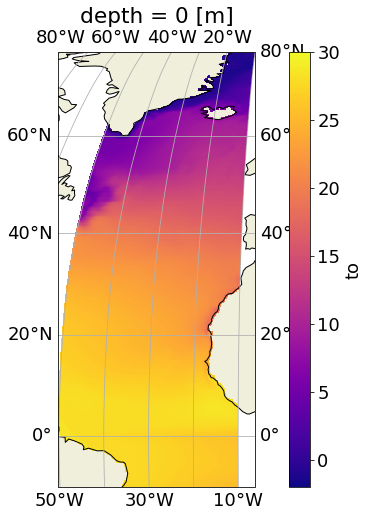

In [64]:
plt.figure()

# Loading the dataset to plot 
data = OCE_OBS.to.mean(dim='time')

# Choosing the projection type & plotting options
projection_map = ccrs.Robinson()
ax = plt.axes(projection=projection_map)
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.add_feature(cfeature.LAND)
# ax.set_extent([-230, -70, -10, 10])

# Plotting the background in color
img = data.plot(ax=ax,transform=ccrs.PlateCarree(),
        cmap = "plasma",
        add_colorbar=True,
        vmax=30,
        vmin=-2,
        label='°C'
        )
# plt.colorbar(img,shrink=0.8,orientation='horizontal',pad=0.02)


## Plot T1_obs/2 S1_obs/2

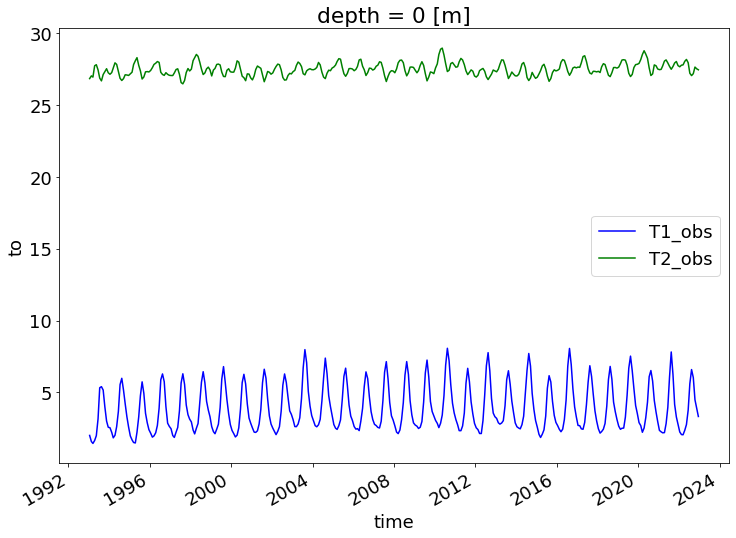

In [11]:
plt.figure()
ax = plt.gca()
T1_obs.plot(ax=ax,color='b',label='T1_obs')
T2_obs.plot(ax=ax,color='g',label='T2_obs')

plt.legend()


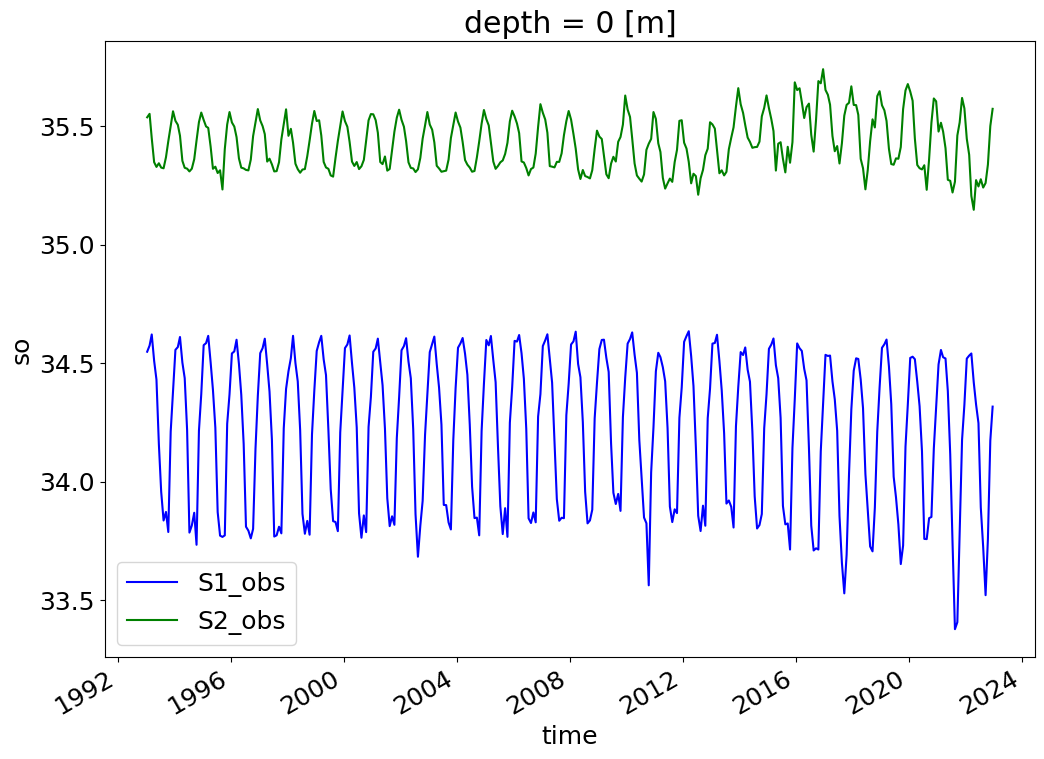

In [12]:
plt.figure()
ax = plt.gca()
S1_obs.plot(ax=ax,color='b',label='S1_obs')
S2_obs.plot(ax=ax,color='g',label='S2_obs')

plt.legend()


## Plot m with T1_obs, T2_obs, S1_obs and S2_obs of observations

Text(0, 0.5, 'AMOC index [Sv]')

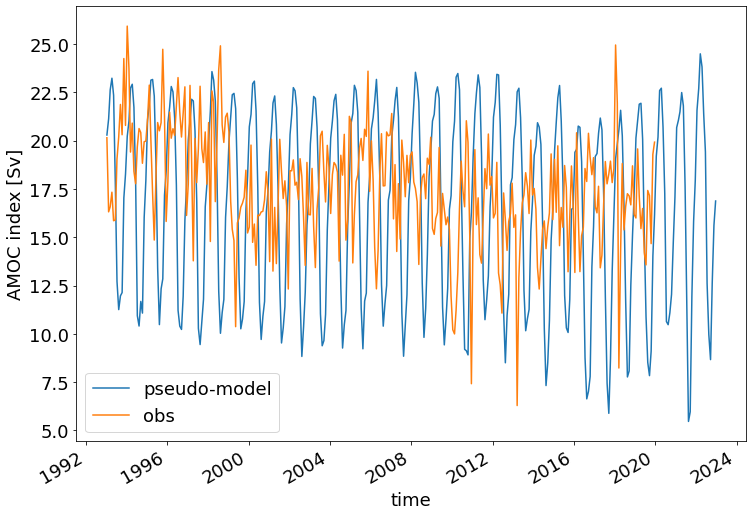

In [12]:
mu = 1.2
delta = 8
# Compute approx AMOC
m = 
m.plot(label='pseudo-model')

# Plot the actual observations (in Sv)
(AMOC_INDEX.amoc_mean * 1e-6).plot(label='obs')

plt.legend()
plt.gca().set_ylabel('AMOC index [Sv]')

# Model

In [ ]:
# Constants
Smoy = 35.0
mu = 6
delta = 8
tau = 10
Vol = 300
T1r = T1_obs.mean().values
T2r = T2_obs.mean().values
S1r = S1_obs.mean().values
F = -0.03

# Differential equations system with F as a parameter
def f2(y):
    # Rename prognostic variables and deduce diagnostic variables
    T1 = y[0]
    T2 = y[1]
    S1 = y[2]
    S2 =
    m =
    
    # Evolution equations
    dT1dt = 
    dT2dt =
    dS1dt =
    
    return np.array([dT1dt, dT2dt, dS1dt])

def integrate_euler_maruyama(T, dt, y0, sigma):
    result = [y0]
    y = y0
    for i in range(int(T / dt)):
        y = y + f2(y) * dt + sigma * np.sqrt(dt) * np.random.normal(size=y0.size)
        result.append(y)
    return np.array(result)

# Initial conditions and noise
y0 = np.array([T1r, T2r, 35])
sigma = np.array([0.05, 0.05, 0.03])

# Integrate the system
sol = integrate_euler_maruyama(10000, 1e-1, y0, sigma)

# Calculate S2 and m
S2 = 2 * Smoy - sol[:, 2]
m = mu * ((sol[:, 1] - sol[:, 0]) - delta * (S2 - sol[:, 2]))

# Plot the results
plt.plot(sol[:, 0])
plt.xlabel('Time')
plt.ylabel('T1')
plt.title('Evolution of T1 over time')
plt.show()

# Dyncamical systems

## The Lorenz's system

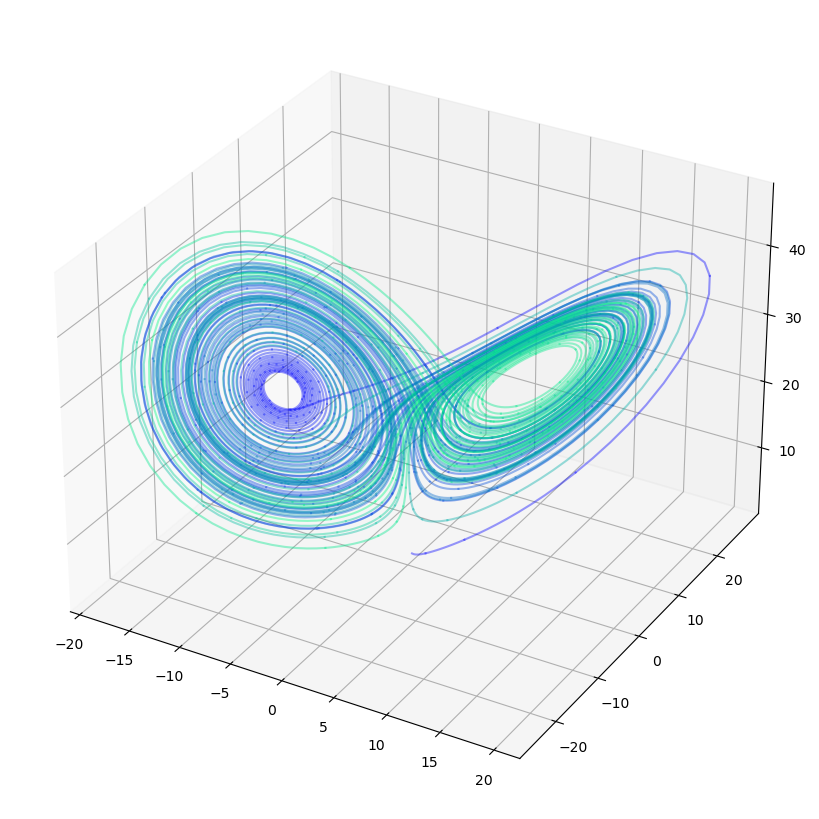

In [9]:
# Create an image of the Lorenz attractor.
# The maths behind this code is described in the scipython blog article
# at https://scipython.com/blog/the-lorenz-attractor/
# Christian Hill, January 2016.
# Updated, January 2021 to use scipy.integrate.solve_ivp.

# Lorenz paramters and initial conditions.
sigma, beta, rho = 10, 2.667, 28
u0, v0, w0 = 0, 1, 1.05

# Maximum time point and total number of time points.
tmax, n = 100, 10000

def lorenz(t, X, sigma, beta, rho):
    """The Lorenz equations."""
    u, v, w = X
    up = -sigma*(u - v)
    vp = rho*u - v - u*w
    wp = -beta*w + u*v
    return up, vp, wp

# Integrate the Lorenz equations.
soln = solve_ivp(lorenz, (0, tmax), (u0, v0, w0), args=(sigma, beta, rho),
                 dense_output=True)
# Interpolate solution onto the time grid, t.
t = np.linspace(0, tmax, n)
x, y, z = soln.sol(t)

# Plot the Lorenz attractor using a Matplotlib 3D projection.
fig = plt.figure()
ax = plt.axes(projection='3d')
# ax.set_facecolor('k')
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

# Make the line multi-coloured by plotting it in segments of length s which
# change in colour across the whole time series.
s = 10
cmap = plt.cm.winter
for i in range(0,n-s,s):
    ax.plot(x[i:i+s+1], y[i:i+s+1], z[i:i+s+1], color=cmap(i/n), alpha=0.4)

# Remove all the axis clutter, leaving just the curve.
# ax.set_axis_off()

plt.show()

## Comparing to observations

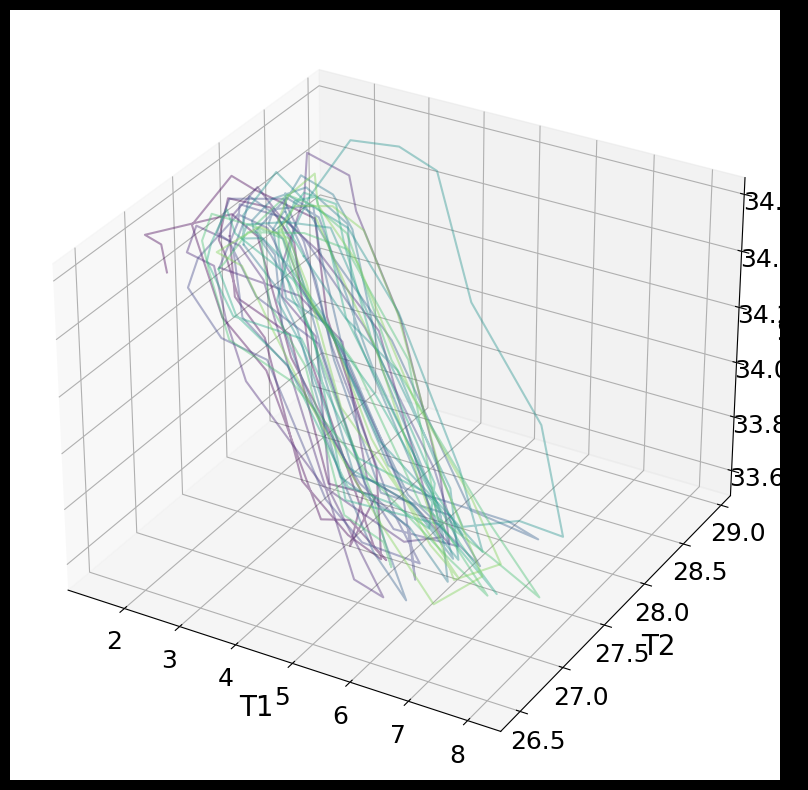

In [81]:
# Plot the Lorenz attractor using a Matplotlib 3D projection.
fig = plt.figure(facecolor='k',figsize=(12,10))
ax = fig.add_subplot(projection = '3d')
ax.set_xlabel('T1_obs', fontsize=20)
ax.set_ylabel('T2_obs', fontsize=20)
ax.set_zlabel('S1_obs', fontsize=20)
#fig.subplots_adjust(left=0, right=10, bottom=0, top=1)

# Make the line multi-coloured by plotting it in segments of length s which
# change in colour across the whole time series.
n = len(T1_obs.time) 
s = n // 10
cmap = plt.cm.viridis#plt.cm.winter
for i in range(0,n-s,s):
    ax.plot(T1_obs[i:i+s+1], T2_obs[i:i+s+1], S1_obs[i:i+s+1], color=cmap(i/n), alpha=0.4)

# Remove all the axis clutter, leaving just the curve.
#ax.set_axis_off()

#plt.savefig('lorenz.png', dpi=DPI)
plt.show()